In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("salary_prediction_data.csv")

In [26]:
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [27]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Experience,1000.0,14.771000,8.341111,1.000000,7.000000,15.000000,22.000000,29.00000
Age,1000.0,42.377000,13.609412,20.000000,30.000000,43.000000,55.000000,64.00000
Salary,1000.0,105558.404239,28256.972075,33510.510669,85032.141517,104314.518315,126804.047524,193016.60215


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   str    
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   str    
 3   Job_Title   1000 non-null   str    
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   str    
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 79.8 KB


In [29]:
df.isnull().sum()

Education     0
Experience    0
Location      0
Job_Title     0
Age           0
Gender        0
Salary        0
dtype: int64

Text(0, 0.5, 'Count Of Individual')

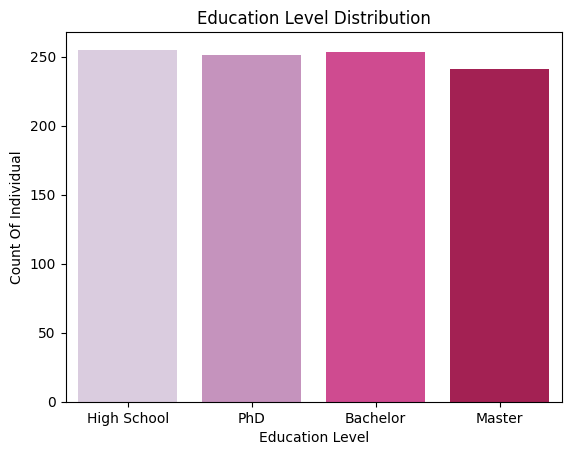

In [31]:
#Visualizing the data
# SE =  Senior Level
# MI = Mid level
# Ex = Executive level
# En = Entry level

sns.countplot(df,x="Education",palette='PuRd',hue='Education')
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count Of Individual")

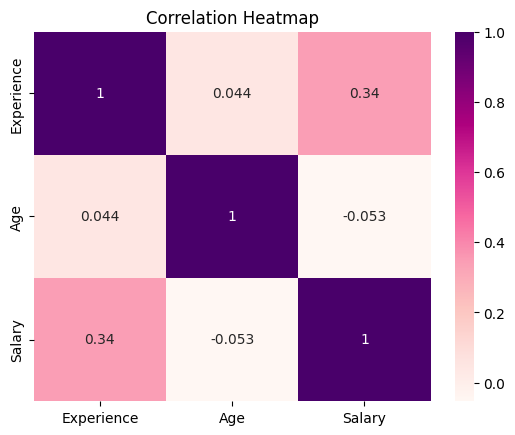

In [32]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),annot=True,cmap="RdPu")
plt.title("Correlation Heatmap")
plt.show()

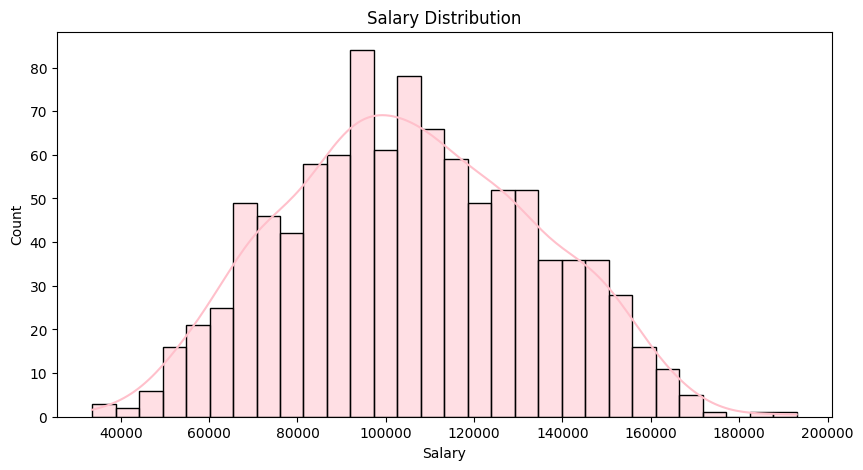

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Salary', bins=30, kde=True, color='pink')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.show()

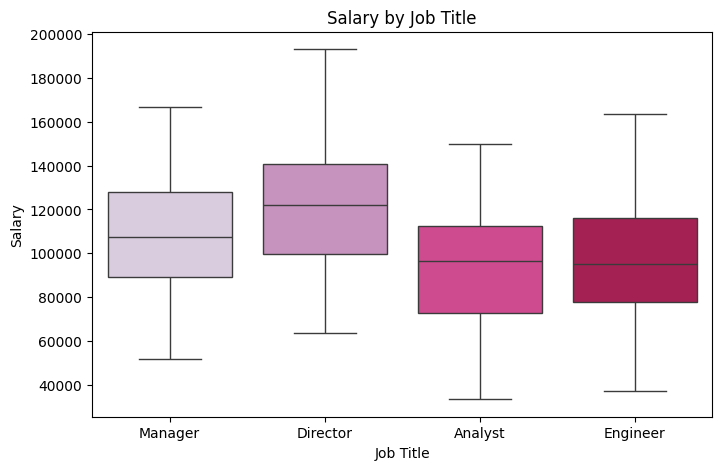

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Job_Title', y='Salary',
            hue='Job_Title', palette='PuRd', legend=False)
plt.title('Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [43]:
X = pd.get_dummies(df.drop('Salary', axis=1))
y = df['Salary']

print("\nFeatures after encoding:", X.columns.tolist())
print("X shape:", X.shape)


Features after encoding: ['Experience', 'Age', 'Education_Bachelor', 'Education_High School', 'Education_Master', 'Education_PhD', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Job_Title_Analyst', 'Job_Title_Director', 'Job_Title_Engineer', 'Job_Title_Manager', 'Gender_Female', 'Gender_Male']
X shape: (1000, 15)


In [44]:
#Train test split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42 )

In [45]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
models = { 
    'Linear Regression' : LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=0.1),
    'Decision Tree' : DecisionTreeRegressor(max_depth=5,random_state=42),
    'Random forest' : RandomForestRegressor(n_estimators=100 , random_state=42),
    'Gradient Boost' : GradientBoostingRegressor(n_estimators=100 , random_state=42),
    'KNN' : KNeighborsRegressor(n_neighbors=5),
}

results = []

for model_name ,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model Name" : model_name,
        'MAE' : round(mean_absolute_error(y_test,y_pred),2),
        'MSE' : round(mean_squared_error(y_test,y_pred),2),
        'R2 score' : round(r2_score(y_test,y_pred),4),
    })
    print(f"✅ {model_name} trained.")

results_df = pd.DataFrame(results)
print(results_df)
 
best = results_df.loc[results_df['R2 score'].idxmax()]
print(f"\n🏆 Best: {best['Model Name']} → R2: {best['R2 score']}")

✅ Linear Regression trained.
✅ Ridge Regression trained.
✅ Lasso Regression trained.
✅ Decision Tree trained.
✅ Random forest trained.
✅ Gradient Boost trained.
✅ KNN trained.
          Model Name       MAE           MSE  R2 score
0  Linear Regression   8157.90  1.059963e+08    0.8702
1   Ridge Regression   8158.31  1.059810e+08    0.8702
2   Lasso Regression   8157.92  1.059961e+08    0.8702
3      Decision Tree  10075.74  1.672122e+08    0.7952
4      Random forest   9321.54  1.310477e+08    0.8395
5     Gradient Boost   8613.60  1.139112e+08    0.8605
6                KNN  10336.03  1.603132e+08    0.8037

🏆 Best: Linear Regression → R2: 0.8702


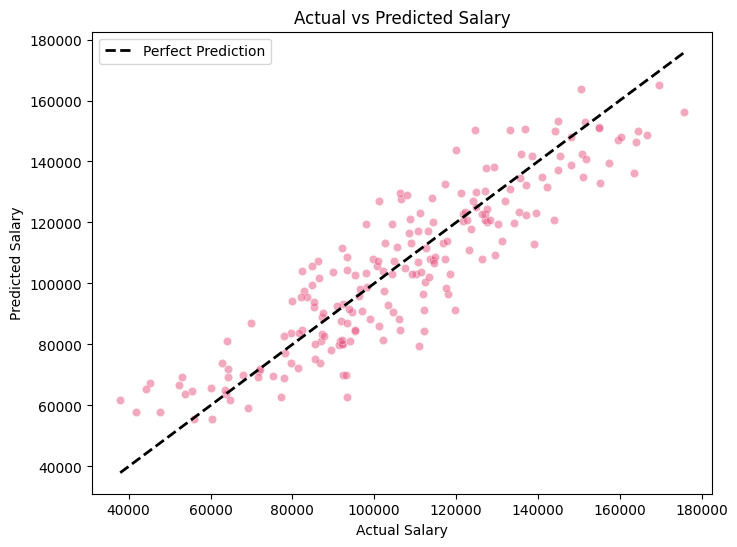

In [ ]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='#e75480')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()


In [52]:
import pickle

with open('salary_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("\n✅ Saved → salary_model.pkl")

with open('salary_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Saved → salary_scaler.pkl")


with open('salary_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('salary_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("\n✅ All pickle files loaded successfully!")


✅ Saved → salary_model.pkl
✅ Saved → salary_scaler.pkl

✅ All pickle files loaded successfully!


In [57]:
new_data = pd.DataFrame([{
    "Experience": 5,
    "Education": "MI",
    "Job_Title": "Data Scientist"
    # add other raw input columns here if your dataset has them
}])

# Convert categorical values the same way as training
new_data = pd.get_dummies(new_data)

# Align to the original training features
# Replace `X.columns` with the actual feature list if running outside the notebook
feature_columns = X.columns
new_data = new_data.reindex(columns=feature_columns, fill_value=0)

# Scale and predict
X_new = loaded_scaler.transform(new_data)
predicted_salary = loaded_model.predict(X_new)

print("Predicted salary:", predicted_salary[0])

Predicted salary: 89046.88435159653
